In [1]:
%load_ext autoreload

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import math
import datetime

plt.rcParams.update({'font.size': 20})
from matplotlib import dates as mdates
#from matplotlib import lines, patches

%autoreload 2
import covid19_inference.covid19_inference as cov19
import utils
import data_prep
import plot
import model

# Input data

## Mobility

In [9]:
path_mobility = "data/mobility/mobilityData_OverviewBL_weekly.csv"
mobility_df = pd.read_csv(path_mobility, parse_dates=True, index_col=0, delimiter=";")
mobility_df = mobility_df[mobility_df["BundeslandID"] == "Deutschland"]
mobility_df["week"] = mobility_df.index.isocalendar().week
#display(mobility_df)

# get dates
mobility_dates = mobility_df.index.values

# get dates
mobility_dates = mobility_df.index.values
all_dates_2020 = mobility_dates[mobility_dates < np.datetime64("2020-12-20")]
mobility_dates_2020 = all_dates_2020[all_dates_2020 > np.datetime64("2020-03-29")]
mobility_dates_2022 = mobility_dates[mobility_dates < np.datetime64("2022-12-20")]
mobility_dates_2022_shortened = mobility_dates_2022[-len(mobility_dates_2020) :]

# get mobility data
mobility_df_2020 = mobility_df.filter(items=mobility_dates_2020, axis=0)
mobility_df_2022 = mobility_df.filter(items=mobility_dates_2022_shortened, axis=0)

mobility_data_2020 = mobility_df_2020["outOfHomeDuration"].to_xarray()
mobility_data_2022 = mobility_df_2022["outOfHomeDuration"].to_xarray()

dates_2020 = pd.to_datetime(mobility_dates_2020)
dates_2022 = pd.to_datetime(mobility_dates_2022_shortened)

### Compare total years

In [5]:
mobility_dates_2020_full = mobility_dates[mobility_dates < np.datetime64('2020-12-27')]
mobility_dates_2020_full = mobility_dates_2020_full[mobility_dates_2020_full > np.datetime64('2019-12-31')]
mobility_dates_2022_full = mobility_dates[mobility_dates < np.datetime64('2023-01-01')]
mobility_dates_2022_full = mobility_dates_2022_full[-len(mobility_dates_2020_full):]

# get mobility data
mobility_df_2020_full = mobility_df.filter(items=mobility_dates_2020_full, axis=0)
mobility_df_2022_full = mobility_df.filter(items=mobility_dates_2022_full, axis=0)

mobility_data_2020_full = mobility_df_2020_full["outOfHomeDuration"].to_xarray()
mobility_data_2022_full = mobility_df_2022_full["outOfHomeDuration"].to_xarray()

In [17]:
mobility_data_2020_full

<xarray.DataArray 'outOfHomeDuration' (date: 42)>
array([7.29, 7.08, 5.91, 5.27, 5.58, 5.64, 5.49, 6.06, 5.95, 6.49, 6.47,
       6.44, 6.95, 6.65, 6.95, 7.28, 7.5 , 7.37, 7.32, 7.43, 7.4 , 7.43,
       7.49, 7.41, 7.46, 7.53, 7.58, 7.76, 7.83, 7.58, 7.5 , 7.61, 7.24,
       7.2 , 7.02, 6.75, 6.85, 6.66, 6.7 , 6.9 , 6.75, 6.17])
Coordinates:
  * date     (date) datetime64[ns] 2020-03-08 2020-03-15 ... 2020-12-20

In [18]:
mobility_data_2022_full

<xarray.DataArray 'outOfHomeDuration' (date: 42)>
array([7.19, 7.15, 7.18, 7.33, 7.47, 7.04, 7.08, 7.71, 7.93, 8.03, 7.95,
       7.54, 8.05, 7.67, 7.83, 7.99, 8.03, 7.96, 7.94, 7.83, 7.79, 7.87,
       7.93, 7.89, 8.04, 8.21, 8.06, 8.04, 8.06, 7.96, 7.68, 7.84, 7.85,
       7.98, 7.41, 7.73, 7.63, 7.56, 7.48, 7.45, 7.38, 7.1 ])
Coordinates:
  * date     (date) datetime64[ns] 2022-03-13 2022-03-20 ... 2022-12-25

Text(36, 2, 'considered period')

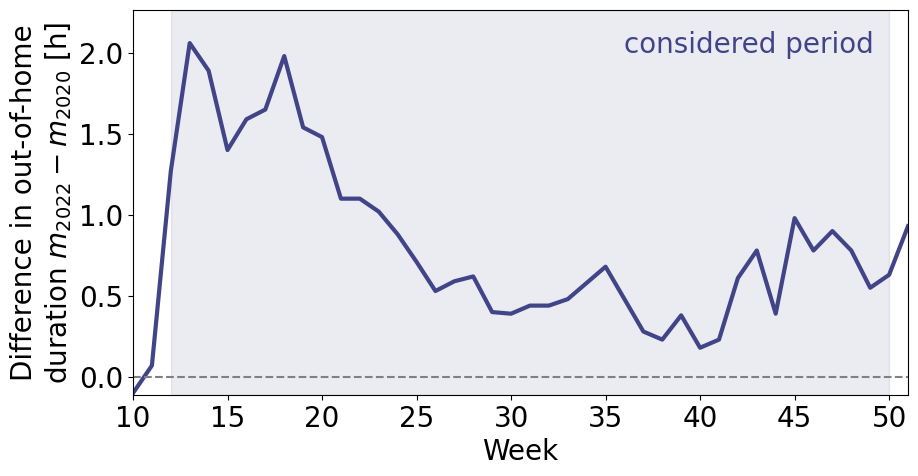

In [47]:
# plot difference between 2020 and 2022
fig, ax = plt.subplots(figsize=(10, 5))
weeks = mobility_df_2020_full.week.values
mobility_difference = mobility_data_2022_full.values - mobility_data_2020_full.values
ax.plot(
    weeks, 
    mobility_difference, 
    linewidth=3,
    color=color_m_obs
    )
ax.set_xlabel("Week")
ax.set_xlim(weeks[0], weeks[-1])
ax.set_ylim(1.1 * mobility_difference.min(), 1.1 * mobility_difference.max())
ax.set_ylabel("Difference in out-of-home\nduration $m_{2022}-m_{2020}$ [h]")
ax.hlines(0, weeks[0], weeks[-1], linestyle="--", color="gray")
ax.axvspan(weeks[2], weeks[-2], alpha=0.1, color=color_m_obs)
ax.text(weeks[26], 2, "considered period", color=color_m_obs)

### Plot

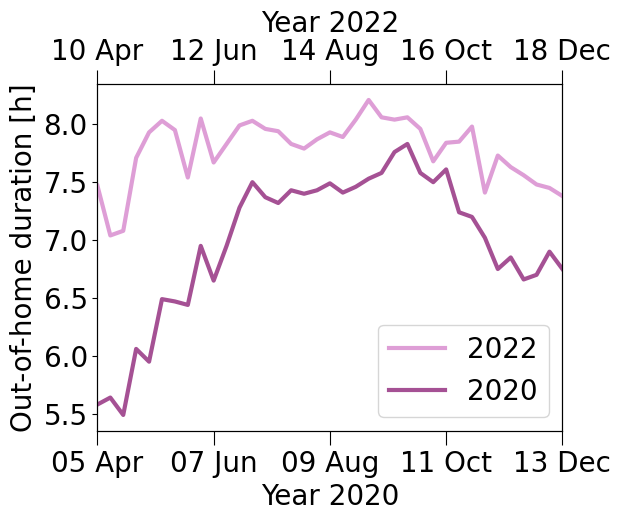

In [16]:
# plot both time series in one panel with twin x axis 
# the lower x-axis should be the mobility_dates_2020
# the upper x-axis should be the mobility_dates_2022_shortened
fig, ax = plt.subplots(figsize=(6, 4.5))

line_2020 = ax.plot(dates_2020, mobility_data_2020, linewidth=3, color=plot.colors["m_obs"], label="2020")
plot.format_x_axis(ax, dates_2020, last=True, n_xticks=5)

ax.set_ylabel("Out-of-home duration [h]")

ax2 = ax.twiny()
line_2022 = ax2.plot(dates_2022, mobility_data_2022, linewidth=3, color=plot.colors["m_base"], label="2022")
plot.format_x_axis(ax2, dates_2022, last=True, n_xticks=5, year=2022)

lines = line_2022 + line_2020
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="lower right")

fig.savefig("figures/mobility_data_2020_2022.pdf", bbox_inches="tight")
fig.savefig("figures/mobility_data_2020_2022.png", bbox_inches="tight")

## Disease indicators

In [127]:
disease_dates = pd.to_datetime(data_prep.get_disease_dates())
full_dates = pd.date_range(start="2020-03-06", end="2020-12-19").values

In [21]:
R_transformed = data_prep.get_R()

path_R = "data/R/Germany/RKI_Nowcasting.csv"
R_df = pd.read_csv(path_R, index_col=0, parse_dates=True)
R_df = R_df.filter(items=full_dates, axis=0)
R_raw = R_df['PS_7_Tage_R_Wert'].values

In [35]:
owid = data_prep.get_owid()

INFO     [covid19_inference.covid19_inference.data_retrieval.retrieval] Successfully loaded OurWorldinData.csv.gz from /data.nst/eiftekhar/covid19/, skipping download.


In [ ]:
C_transformed = data_prep.get_C(owid)
case_data = owid._filter(
        value="new_cases_smoothed_per_million",
        country="Germany",
    )
case_data = case_data.filter(items=full_dates, axis=0)
cases_raw = case_data.values

In [66]:
disease_dates_ICU = pd.to_datetime(data_prep.get_disease_dates(ICU=True))
full_dates_ICU = pd.date_range(start="2020-03-22", end="2020-12-19").values
ICU_transformed = data_prep.get_ICU(owid)
ICU_data = owid._filter(
        value="icu_patients_per_million",
        country="Germany",
    )
ICU_data = ICU_data.filter(items=full_dates_ICU, axis=0)
ICU_raw = ICU_data.values

In [71]:
H_transformed = data_prep.get_H(owid)
hospital_data = owid._filter(
        value="weekly_hosp_admissions_per_million",
        country="Germany",
    )
hospital_data = hospital_data.filter(items=full_dates, axis=0)
hospital_raw = hospital_data.values

In [91]:
def plot_indicator(ax, indicator, raw_data, label_in, title_in, transformed_data, transformed_label, last=False):
    if indicator == "ICU":
        raw_dates = full_dates_ICU
        transformed_dates = disease_dates_ICU
    else:
        raw_dates = full_dates
        transformed_dates = disease_dates

    ax.plot(raw_dates, raw_data, color=plot.colors[indicator], marker="o")
    ax.set_ylabel(label_in)
    ax.set_title(title_in)
    if indicator == "R":
        ax.hlines(1, raw_dates[0], raw_dates[-1], linestyle="--", color="gray")
    else:
        ax.set_ylim(0, max(raw_data) * 1.1)
    ax = ax.twinx()
    ax.plot(transformed_dates, transformed_data, color=plot.colors[indicator], linewidth=3)
    ax.set_ylabel(transformed_label)
    ax.set_ylim(0, 1)
    plot.format_x_axis(ax, disease_dates, last=last)
    if indicator == "ICU":
        ## create custom legend
        ### for median line and 94% CI
        raw = lines.Line2D([], [], color="black", marker='o', label="raw")
        transformed = lines.Line2D([], [], color="black", linewidth=3, label="transformed")
        ### create legend
        ax.legend(
            handles=[raw, transformed],
            #frameon=False,
            loc="upper center",
        )

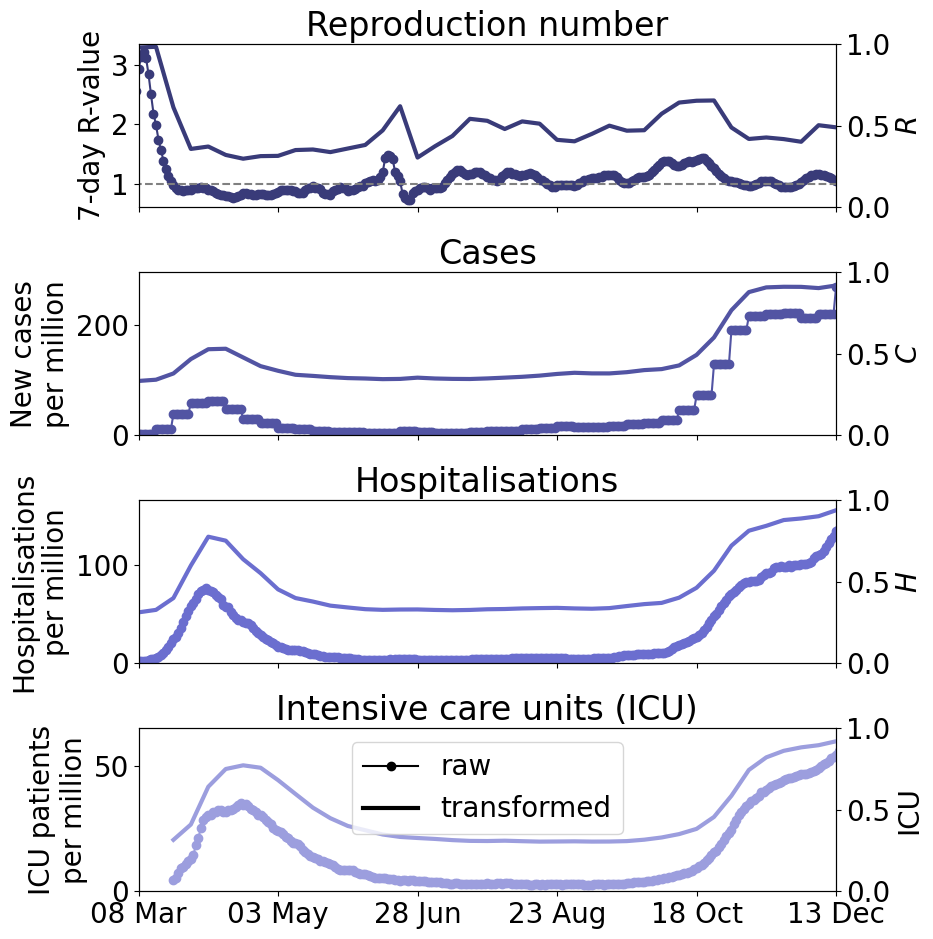

In [92]:
fig, axs = plt.subplots(4, 1, figsize=(9, 11))
plot_indicator(axs[0], "R", R_raw, "7-day R-value", "Reproduction number", R_transformed, "$R$")
plot_indicator(axs[1], "C", cases_raw, "New cases\nper million", "Cases", C_transformed, "$C$")
plot_indicator(axs[2], "H", hospital_raw, "Hospitalisations\nper million", "Hospitalisations", H_transformed, "$H$")
plot_indicator(axs[3], "ICU", ICU_raw, "ICU patients\nper million", "Intensive care units (ICU)", ICU_transformed, "ICU", last=True)
fig.subplots_adjust(hspace=0.4)

fig.savefig("figures/disease_spread_indicators.pdf", bbox_inches="tight")
fig.savefig("figures/disease_spread_indicators.png", bbox_inches="tight")

## Non-pharmaceutical interventions (NPIs)

### Ausgangsbeschränkungen / -Sperren

In [83]:
df = pd.read_csv('data/NPIs/StayAtHomeOrders - Werte.csv')

In [84]:
# iterate through every row of the data frame to make date column
for index, row in df.iterrows():
    # create date object from Day, Month, Year columns
    date = datetime.date(row['Year'], row['Month'], row['Day'])
    # make date to pandas datetime format
    date = pd.to_datetime(date)
    # add date object to new column
    df.loc[index, 'Date'] = date

df.head()

,Day,Month,Year,Value Schleswig-Holstein,Comment SH,Value Hamburg,Comment HH,Value Niedersachsen,Comment NI,Value Bremen,...,Comment BB,Value Mecklenburg-Vorpommern,Comment MV,Value Sachsen,Comment SN,Value Sachsen-Anhalt,Comment ST,Value Thüringen,Comment Thüringen,Date
0,22,3,2020,0,https://www.sueddeutsche.de/gesundheit/krankhe...,0,Keine Ausgangssperre vor 2021: https://www.wel...,0,Nichts gefunden hier: https://www.niedersachse...,0,...,"""Das Betreten öffentlicher Orte wird bis zum 1...",0,Ich finde hier https://kripoz.de/wp-content/up...,0,NaN,0,NaN,0,"""Der Aufenthalt im öffentlichen Raum ist nur a...",2020-03-22
1,29,3,2020,0,NaN,0,NaN,0,NaN,0,...,NaN,0,NaN,1,"""Das Verlassen der häuslichen Unterkunft ohne ...",1,Ab dem 24.03.: https://www.landesrecht-sachsen...,0,NaN,2020-03-29
2,5,4,2020,0,NaN,0,NaN,0,NaN,0,...,NaN,0,NaN,1,s. auch: https://web.archive.org/web/202003222...,1,NaN,0,NaN,2020-04-05
3,12,4,2020,0,NaN,0,NaN,0,NaN,0,...,NaN,0,NaN,1,NaN,1,NaN,0,NaN,2020-04-12
4,19,4,2020,0,NaN,0,NaN,0,NaN,0,...,NaN,0,NaN,1,NaN,1,NaN,0,NaN,2020-04-19


In [104]:
# create empty dataframe with dates as index
df_new = pd.DataFrame(index=df["Date"].values)

for column_name in df.columns.values:
    if column_name[:5] == "Value":
        _, state = column_name.split(" ")
        df_new[state] = df[column_name].values

# transpose dataframe
df_new = df_new.T

# order rows alphabetically
df_new = df_new.sort_index()

population = pd.read_csv('data/population_bundesland.csv', sep=';', index_col=0)
population["Einwohner"] = population["Einwohner"].apply(utils.population_string_to_number)

weighted_averages = []

for column in df_new.columns.values:
    value = 0
    for index, row in df_new.iterrows():
        value += population.loc[index]["Einwohner"] * row[column]
    value /= population["Einwohner"].sum()
    weighted_averages.append(value)

# add new row to dataframe
df_new.loc["weighted average"] = weighted_averages

df_new.head()

,2020-03-22,2020-03-29,2020-04-05,2020-04-12,2020-04-19,2020-04-26,2020-05-03,2020-05-10,2020-05-17,2020-05-24,...,2020-10-11,2020-10-18,2020-10-25,2020-11-01,2020-11-08,2020-11-15,2020-11-22,2020-11-29,2020-12-06,2020-12-13
Baden-Württemberg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Bayern,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Berlin,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Brandenburg,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Bremen,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [119]:
data_prep.get_S(mobility_dates_2020)

<xarray.DataArray 'stay_at_home_orders' (index: 37)>
array([0.31941195, 0.31941195, 0.31941195, 0.22665918, 0.22665918,
       0.03048962, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.34052874])
Coordinates:
  * index    (index) datetime64[ns] 2020-04-05 2020-04-12 ... 2020-12-13

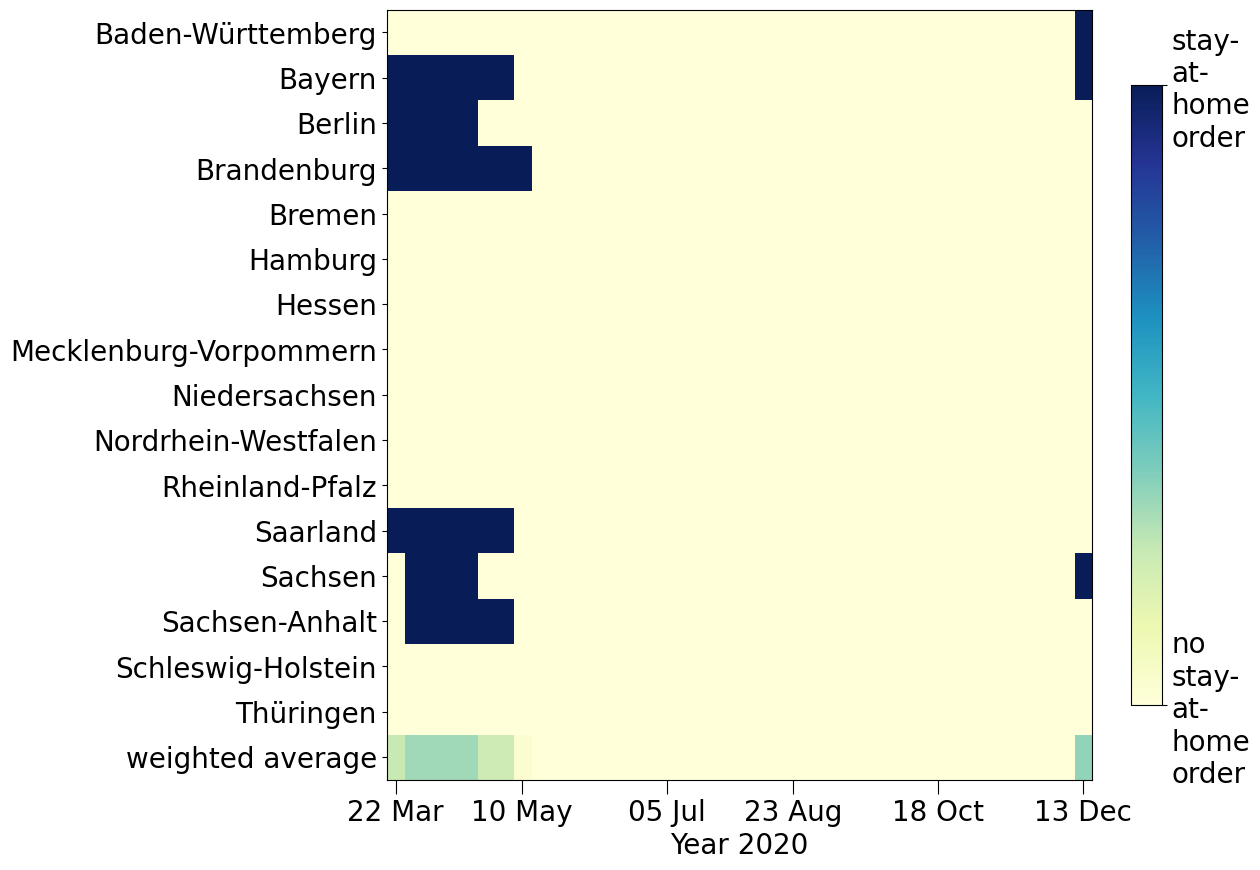

In [113]:
# make heatmap of df_new
cmap = 'YlGnBu'
colormap = plt.cm.YlGnBu

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(df_new, cmap=cmap, aspect='auto')

# get x tick locations
dates = [pd.to_datetime(str(x)) for x in df_new.columns.values]
xticks = np.linspace(0, len(dates)-1, 6, dtype=int)
# get x tick labels
xticklabels = [dates[i].strftime("%d %b") for i in xticks]
# set x ticks
ax.set_xticks(xticks)
# increase x tick length
ax.tick_params(axis="x", length=10)

# set x tick labels
ax.set_xticklabels(xticklabels)
ax.set_xlabel("Year 2020")

# set all states as y ticks
ax.set_yticks(np.arange(len(df_new.index)))
ax.set_yticklabels(df_new.index.values)

## create custom legend
# ### for median line and 94% CI
# order = patches.Patch(color=colormap(0.99), label="stay-at-home order")
# no_order = patches.Patch(color=colormap(0.0), label="no stay-at-home order")
# ### create legend
# legend2 = ax.legend(
#     handles=[order, no_order],
#     loc="lower right",
# )
# ax.add_artist(legend2)

# add  short colorbar
cbar = ax.figure.colorbar(im, ax=ax, fraction=0.04)
# set colorbar ticks and ticklabels
cbar.ax.set_yticks([0,1])
cbar.ax.set_yticklabels(['no\nstay-\nat-\nhome\norder', 'stay-\nat-\nhome\norder'])

# save figure
fig.savefig("figures/stay_at_home.png", dpi=300, bbox_inches="tight")
fig.savefig("figures/stay_at_home.pdf", dpi=300, bbox_inches="tight")

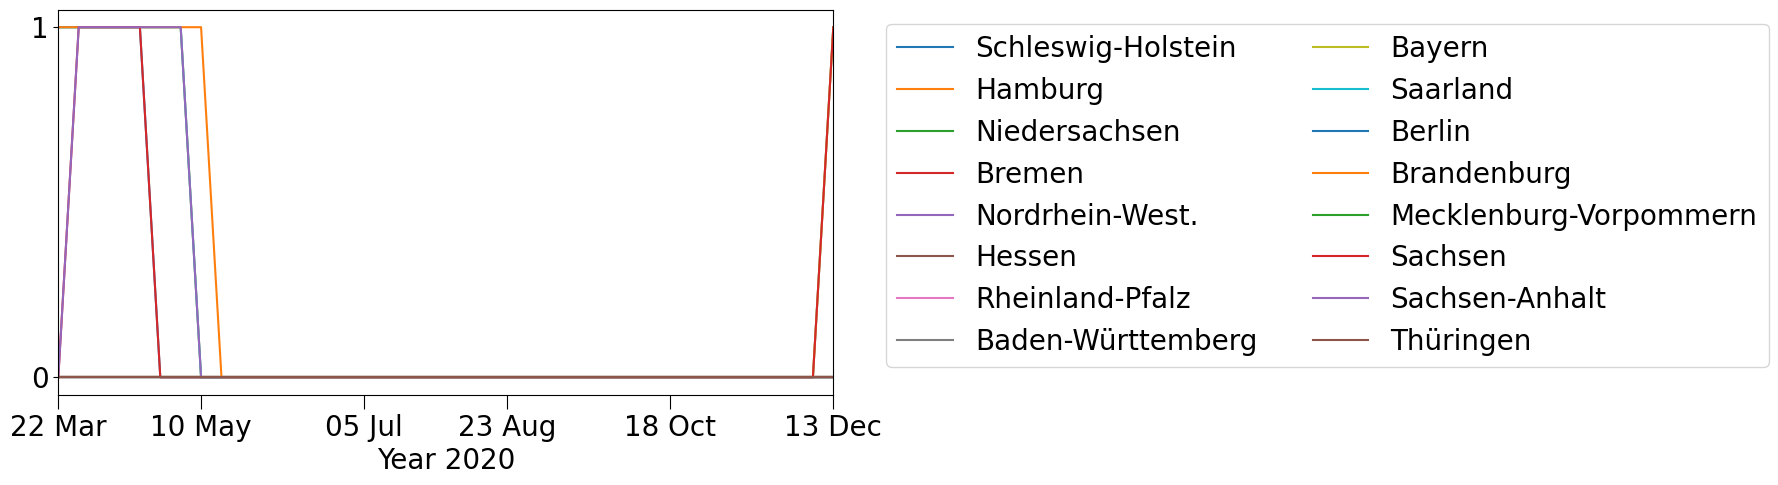

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))

for column_name in df.columns.values:
    if column_name[:5] == "Value":
        _, state = column_name.split(" ")

        ax.plot(df["Date"].values, df[column_name].values, label=state)

ax.legend(bbox_to_anchor=(1.05, 1), ncol=2)
format_x_axis(ax, df["Date"].values, last=True)

# only have 0 and 1 as y-ticks
ax.set_yticks([0, 1])

### OxCGRT

In [34]:
stay_at_home_2020 = utils.get_NPI_data("data/NPIs/stay-at-home-covid.csv", mobility_dates_2020)
movement_restrictions_2020 = utils.get_NPI_data("data/NPIs/internal-movement-covid.csv", mobility_dates_2020)
public_transport_2020 = utils.get_NPI_data("data/NPIs/public-transport-covid.csv", mobility_dates_2020)
school_closures_2020 = utils.get_NPI_data("data/NPIs/school-closures-covid.csv", mobility_dates_2020, stay_home=False)
workplace_closures_2020 = utils.get_NPI_data("data/NPIs/workplace-closures-covid.csv", mobility_dates_2020, stay_home=False)

school_closures_2022 = utils.get_NPI_data("data/NPIs/school-closures-covid.csv", mobility_dates_2022_shortened, stay_home=False)
workplace_closures_2022 = utils.get_NPI_data("data/NPIs/workplace-closures-covid.csv", mobility_dates_2022_shortened, stay_home=False)

/data/eiftekhar/mobility_inference/utils.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = df.resample("7D").mean()
/data/eiftekhar/mobility_inference/utils.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = df.resample("7D").mean()
/data/eiftekhar/mobility_inference/utils.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = df.resample("7D").mean()
/data/eiftekhar/mobility_inference/utils.py:15: F

In [25]:
meaning_index = {0: "none", 1: "recommended", 2: "required\n(partly)", 3: "required\n(fully)"}
yticklabels = list(meaning_index.values())

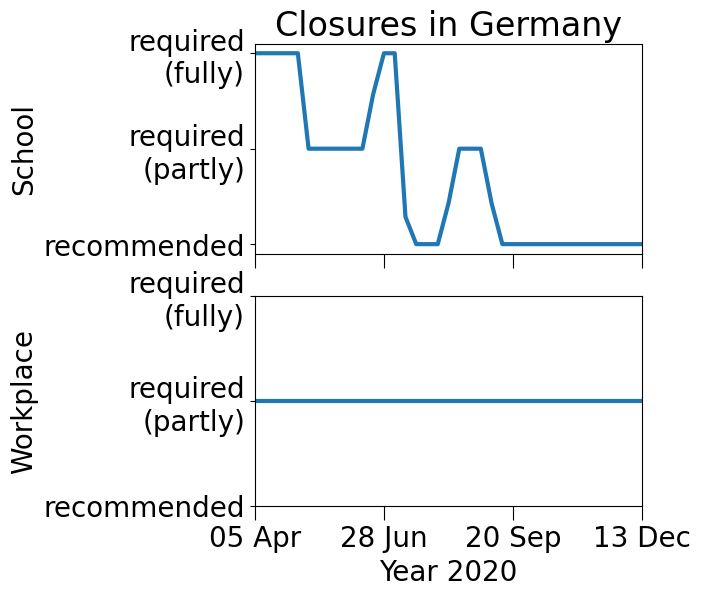

In [44]:
fig, axs = plt.subplots(2, 1, figsize=(5, 6), sharex=True)
n_xticks = 4

ax = axs[0]
ax.set_title("Closures in Germany")
ax.plot(mobility_dates_2020, school_closures_2020, linewidth=3, label="2020")
ax.set_ylabel("School")
# yticks
yticks = [1, 2, 3]
ax.set_yticks(yticks)
ax.set_yticklabels([yticklabels[i] for i in yticks])
format_x_axis(ax, mobility_dates_2020, n_xticks=n_xticks)

ax = axs[1]
ax.plot(mobility_dates_2020, workplace_closures_2020, linewidth=3, label="2020")
ax.set_ylabel("Workplace")
# yticks
yticks = [1, 2, 3]
ax.set_yticks(yticks)
ax.set_yticklabels([yticklabels[i] for i in yticks])
format_x_axis(ax, mobility_dates_2020, n_xticks=n_xticks, last=True)

# save figure
fig.savefig("figures/closures.pdf", bbox_inches="tight")
fig.savefig("figures/closures.png", bbox_inches="tight")

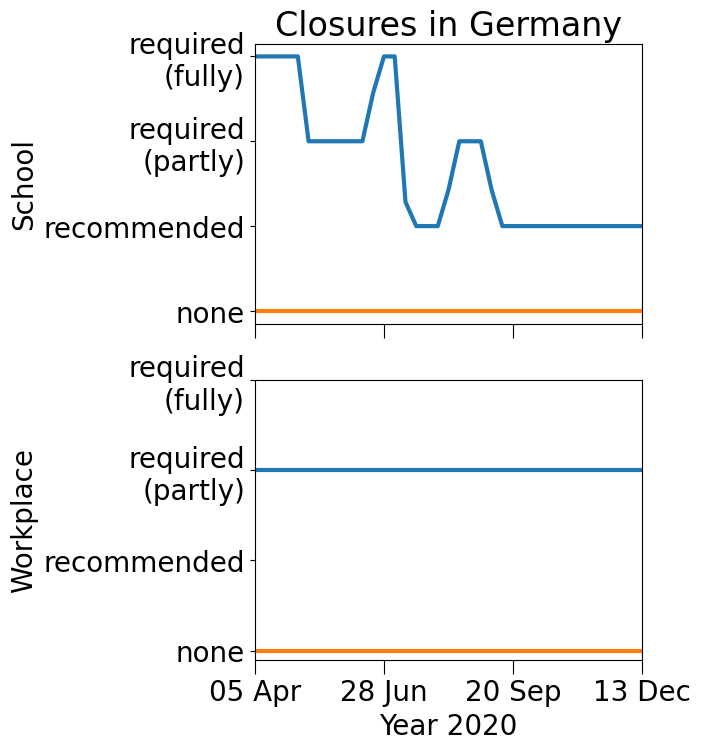

In [38]:
fig, axs = plt.subplots(2, 1, figsize=(5, 8), sharex=True)
n_xticks = 4

ax = axs[0]
ax.set_title("Closures in Germany")
ax.plot(mobility_dates_2020, school_closures_2020, linewidth=3, label="2020")
ax.plot(mobility_dates_2020, school_closures_2022, linewidth=3, label="2022")
ax.set_ylabel("School")
# yticks
ax.set_yticks(list(meaning_index.keys()))
ax.set_yticklabels(list(meaning_index.values()))
format_x_axis(ax, mobility_dates_2020, n_xticks=n_xticks)

ax = axs[1]
ax.plot(mobility_dates_2020, workplace_closures_2020, linewidth=3, label="2020")
ax.plot(mobility_dates_2020, workplace_closures_2022, linewidth=3, label="2022")
ax.set_ylabel("Workplace")
# yticks
ax.set_yticks(list(meaning_index.keys()))
ax.set_yticklabels(list(meaning_index.values()))
format_x_axis(ax, mobility_dates_2020, n_xticks=n_xticks, last=True)

Text(0.5, 1.0, 'Stay-at-home-orders in Germany')

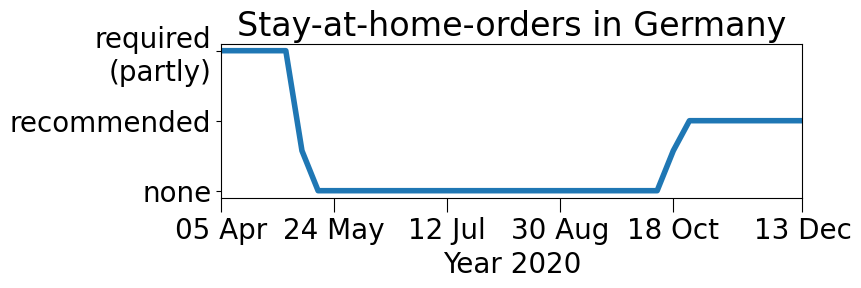

In [22]:
fig, ax = plt.subplots(figsize=(7.5, 2))
linewidth = 4
ax.plot(mobility_dates_2020, stay_at_home_2020, linewidth=linewidth, label="Stay-at-home order")
#ax.set_ylabel("Index")
# yticks
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(yticklabels[:-1])
format_x_axis(ax, mobility_dates_2020, last=True)
#ax.legend(bbox_to_anchor=(0.77, -0.5))
ax.set_title("Stay-at-home-orders in Germany")#\n(higher index = stricter)")

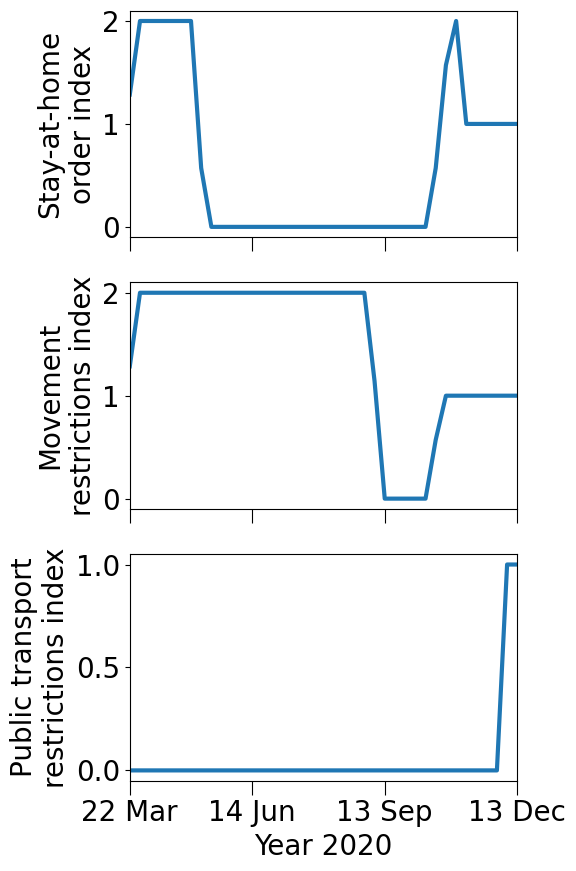

In [38]:
fig, axs = plt.subplots(3, 1, figsize=(5, 10), sharex=True)
n_xticks = 4

ax = axs[0]
ax.plot(mobility_dates_2020, stay_at_home_2020, linewidth=3)
ax.set_ylabel("Stay-at-home\norder index")
format_x_axis(ax, mobility_dates_2020, n_xticks=n_xticks)

ax = axs[1]
ax.plot(mobility_dates_2020, movement_restrictions_2020, linewidth=3)
ax.set_ylabel("Movement\nrestrictions index")
format_x_axis(ax, mobility_dates_2020, n_xticks=n_xticks)

ax = axs[2]
ax.plot(mobility_dates_2020, public_transport_2020, linewidth=3)
ax.set_ylabel("Public transport\nrestrictions index")
format_x_axis(ax, mobility_dates_2020, last=True, n_xticks=n_xticks)

Text(0.5, 1.0, 'Mobility-related non-pharmaceutical\ninterventions in Germany\n(higher index = stricter)')

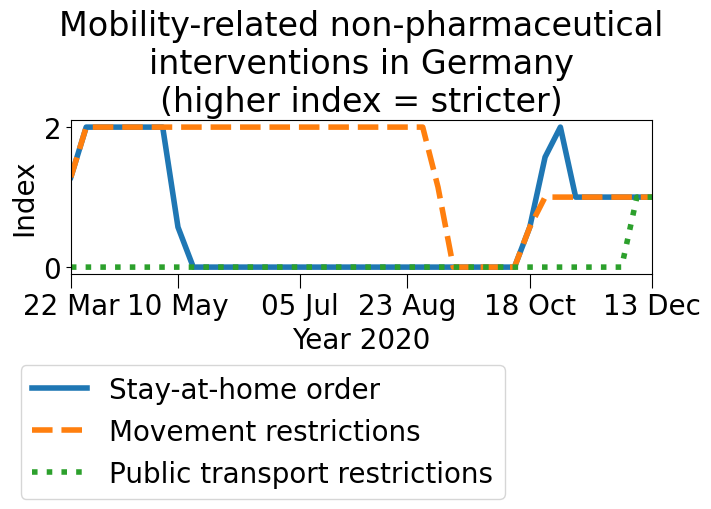

In [65]:
fig, ax = plt.subplots(figsize=(7.5, 2))
linewidth = 4
ax.plot(mobility_dates_2020, stay_at_home_2020, linewidth=linewidth, label="Stay-at-home order")
ax.plot(mobility_dates_2020, movement_restrictions_2020, linewidth=linewidth, label="Movement restrictions", linestyle="--")
ax.plot(mobility_dates_2020, public_transport_2020, linewidth=linewidth, label="Public transport restrictions", linestyle=":")
ax.set_ylabel("Index")
format_x_axis(ax, mobility_dates_2020, last=True)
ax.legend(bbox_to_anchor=(0.77, -0.5))
ax.set_title("Mobility-related non-pharmaceutical\ninterventions in Germany\n(higher index = stricter)")

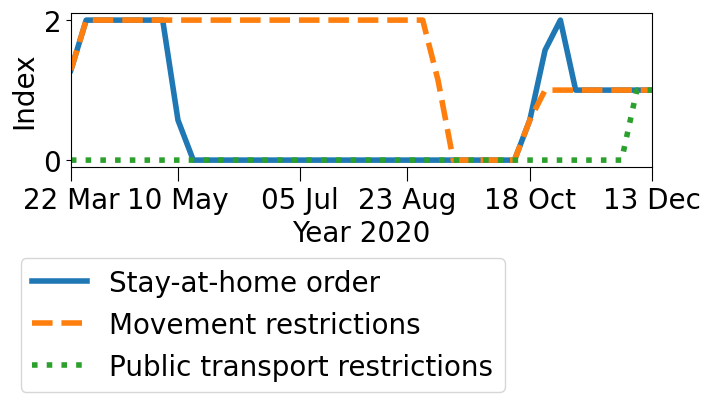

In [66]:
fig, ax = plt.subplots(figsize=(7.5, 2))
linewidth = 4
ax.plot(mobility_dates_2020, stay_at_home_2020, linewidth=linewidth, label="Stay-at-home order")
ax.plot(mobility_dates_2020, movement_restrictions_2020, linewidth=linewidth, label="Movement restrictions", linestyle="--")
ax.plot(mobility_dates_2020, public_transport_2020, linewidth=linewidth, label="Public transport restrictions", linestyle=":")
ax.set_ylabel("Index")
format_x_axis(ax, mobility_dates_2020, last=True)
ax.legend(bbox_to_anchor=(0.77, -0.5))
#ax.set_title("Mobility-related non-pharmaceutical\ninterventions in Germany\n(higher index = stricter)")

### Total timelines

c:\Users\iftek\Documents\MPI\mobility inference\mobility_inference\utils.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = df.resample("7D").mean()


<AxesSubplot: xlabel='Day'>

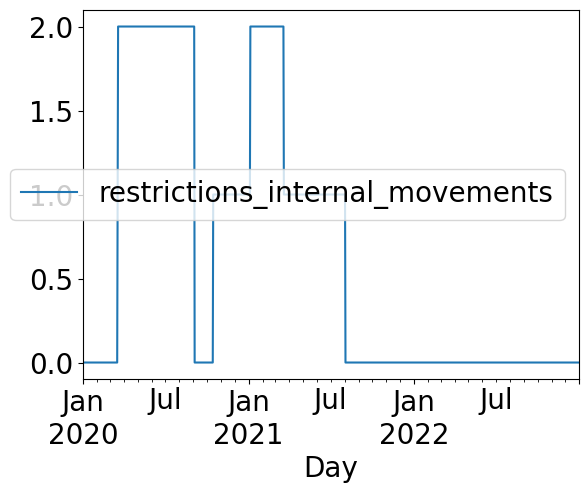

In [63]:
df_movement_restrictions = pd.read_csv("data/NPIs/internal-movement-covid.csv", parse_dates=True, index_col=2)
df_movement_restrictions = df_movement_restrictions[df_movement_restrictions["Entity"] == "Germany"]

# plot movement restrictions
df_movement_restrictions.plot()

<AxesSubplot: xlabel='Day'>

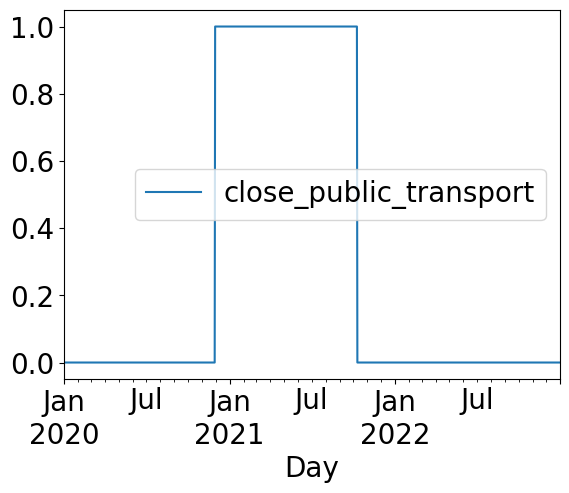

In [66]:
df_public_transport = pd.read_csv("data/NPIs/public-transport-covid.csv", parse_dates=True, index_col=2)
df_public_transport = df_public_transport[df_public_transport["Entity"] == "Germany"]

# plot movement restrictions
df_public_transport.plot()

<AxesSubplot: xlabel='Day'>

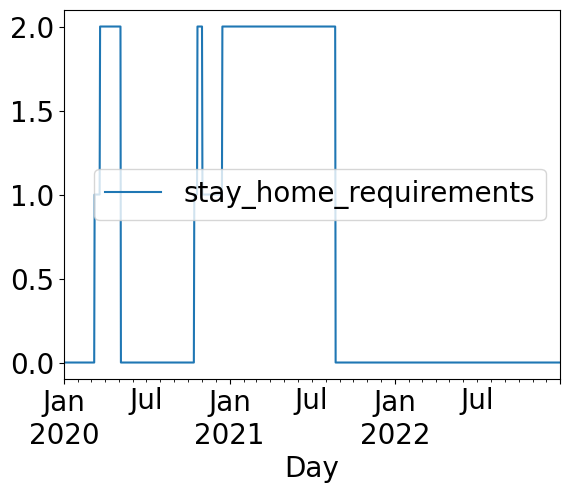

In [70]:
df_stay_at_home = pd.read_csv("data/NPIs/stay-at-home-covid.csv", parse_dates=True, index_col=2)
df_stay_at_home = df_stay_at_home[df_stay_at_home["Entity"] == "Germany"]

# plot movement restrictions
df_stay_at_home.plot()

<Axes: xlabel='Day'>

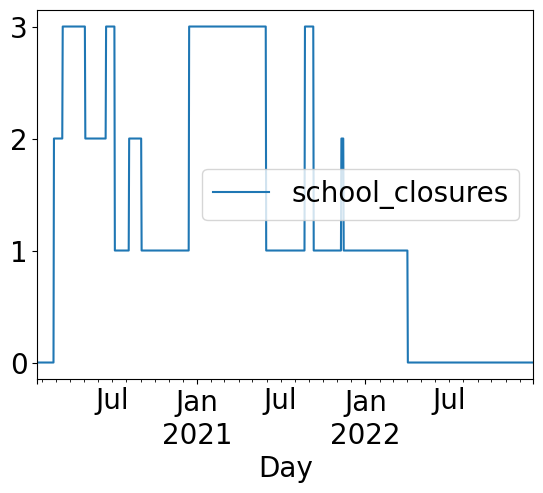

In [23]:
df = pd.read_csv("data/NPIs/school-closures-covid.csv", parse_dates=True, index_col=2)
df = df[df["Entity"] == "Germany"]

# plot movement restrictions
df.plot()

<Axes: xlabel='Day'>

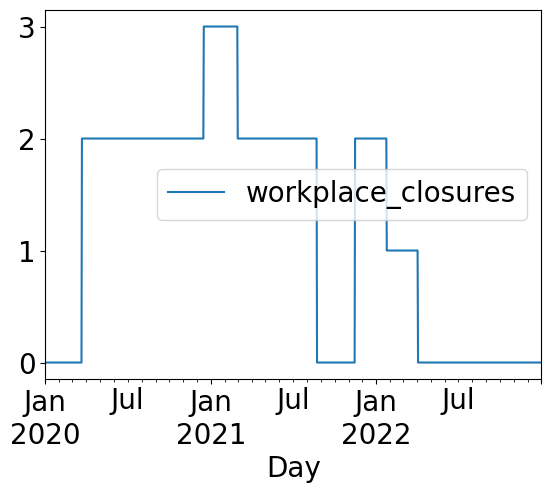

In [24]:
df = pd.read_csv("data/NPIs/workplace-closures-covid.csv", parse_dates=True, index_col=2)
df = df[df["Entity"] == "Germany"]

# plot movement restrictions
df.plot()

## Weather data

In [13]:
df_2020, df_2022 = data_prep.get_weather_dfs(dates_2020, dates_2022)

In [11]:
temperature = {
        "average": data_prep.get_avg_T(dates_2020, dates_2022),
        "delta": data_prep.get_delta_T(dates_2020, dates_2022),
    }
precipitation = data_prep.get_delta_prcp(dates_2020, dates_2022)

### Plot

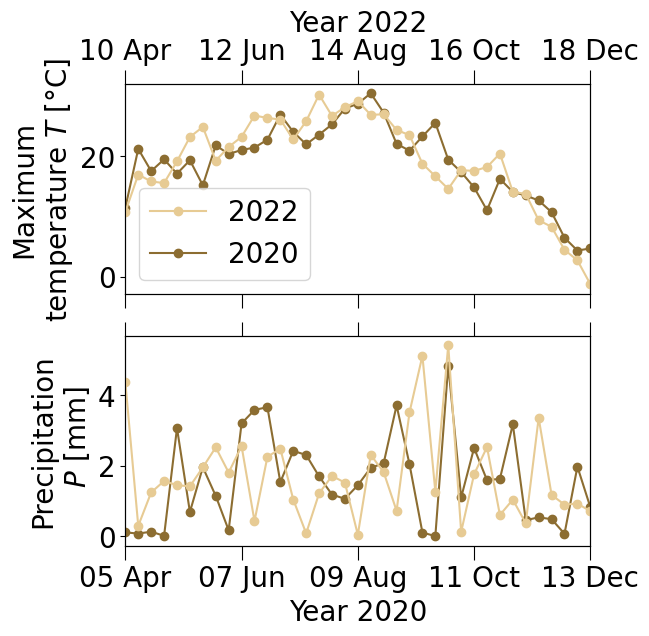

In [28]:
fig, axs = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

ax = axs[0]
#ax.set_title("Weather in Germany")
ax.set_ylabel("Maximum\ntemperature $T$ [°C]")

line_2020 = ax.plot(dates_2020, df_2020["tmax"], marker="o", color=plot.colors["T"], label="2020")
plot.format_x_axis(ax, dates_2020, n_xticks=5)

ax2 = ax.twiny()
line_2022 = ax2.plot(dates_2022, df_2022["tmax"], marker="o", color=plot.colors["w_2022"], label="2022")
plot.format_x_axis(ax2, dates_2022, last=True, n_xticks=5, year=2022)

lines = line_2022 + line_2020
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="lower left")

ax = axs[1]
ax.set_ylabel("Precipitation\n $P$ [mm]")

line_2020 = ax.plot(dates_2020, df_2020["prcp"], marker="o", color=plot.colors["T"], label="2020")
plot.format_x_axis(ax, dates_2020, last=True, n_xticks=5)

ax2 = ax.twiny()
line_2022 = ax2.plot(dates_2022, df_2022["prcp"], marker="o", color=plot.colors["w_2022"], label="2022")
plot.format_x_axis(ax2, dates_2022, n_xticks=5, year=2022)

fig.savefig("figures/weather.pdf", bbox_inches="tight")
fig.savefig("figures/weather.png", bbox_inches="tight")

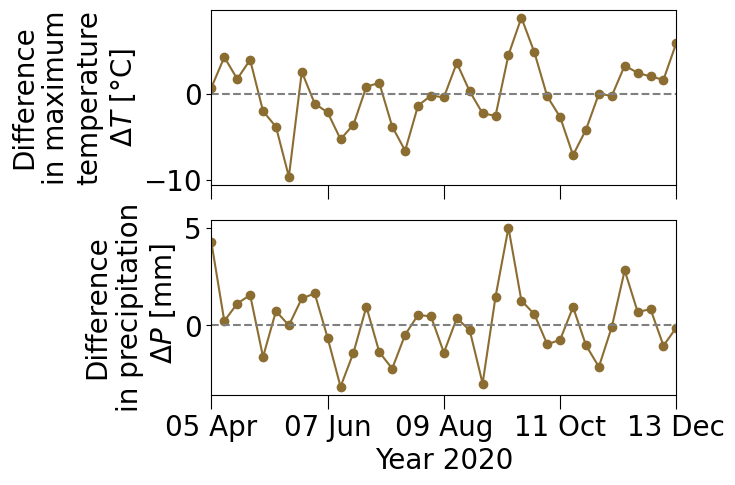

In [33]:
fig, axs = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

ax = axs[0]
#ax.set_title("Weather in Germany")
ax.set_ylabel("Difference\nin maximum\ntemperature\n$\Delta T$ [°C]")

line_2020 = ax.plot(dates_2020, temperature["delta"], marker="o", color=plot.colors["T"], label="2020")
ax.hlines(0, dates_2020[0], dates_2020[-1], linestyle="--", color="gray")
plot.format_x_axis(ax, dates_2020, n_xticks=5)

ax = axs[1]
ax.set_ylabel("Difference\nin precipitation\n $\Delta P$ [mm]")

line_2020 = ax.plot(dates_2020, precipitation, marker="o", color=plot.colors["T"], label="2020")
ax.hlines(0, dates_2020[0], dates_2020[-1], linestyle="--", color="gray")
plot.format_x_axis(ax, dates_2020, last=True, n_xticks=5)

fig.savefig("figures/weather_differences.pdf", bbox_inches="tight")
fig.savefig("figures/weather_differences.png", bbox_inches="tight")

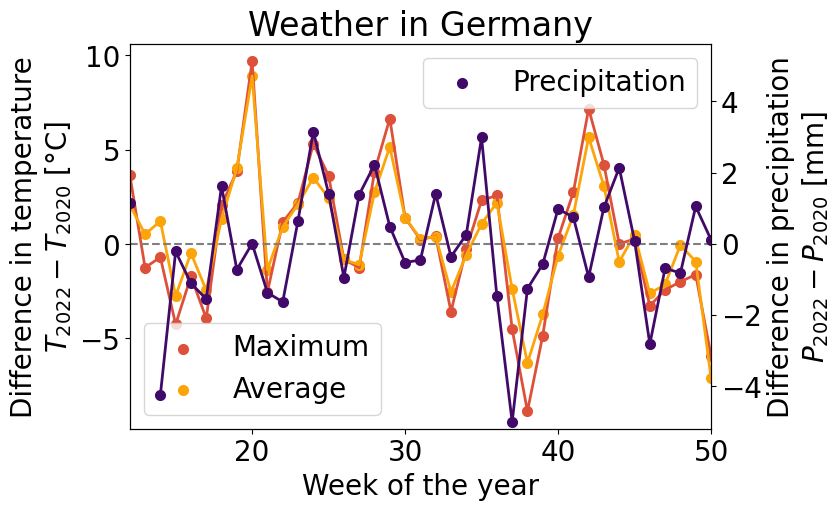

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(7.5, 5))
linewidth = 2
weeks = mobility_df_2020.week.values

# differences
delta_tmax = weather_df_2022["tmax"].values - weather_df_2020["tmax"].values
delta_tavg = weather_df_2022["tavg"].values - weather_df_2020["tavg"].values
delta_precipitation = -(weather_df_2022["prcp"].values - weather_df_2020["prcp"].values)

ax.set_title("Weather in Germany")
ax.scatter(weeks, delta_tmax, linewidth=linewidth, label="Maximum", color=Tmax_color)
ax.plot(weeks, delta_tmax, linewidth=linewidth, color=Tmax_color)
ax.scatter(weeks, delta_tavg, linewidth=linewidth, label="Average", color=Tavg_color)
ax.plot(weeks, delta_tavg, linewidth=linewidth, color=Tavg_color)
ax.hlines(0, weeks[0], weeks[-1], linestyle="--", color="grey")
ax.set_ylabel("Difference in temperature\n$T_{2022} - T_{2020}$ [°C]")
ax.legend()
format_x_axis(ax, weeks, last=True)

ax = ax.twinx()
ax.scatter(weeks, delta_precipitation, linewidth=linewidth, color=precipitiaton_color, label="Precipitation")
ax.plot(weeks, delta_precipitation, linewidth=linewidth, color=precipitiaton_color)
#ax.hlines(0, weeks[0], weeks[-1], linestyle="--", color="red")
ax.set_ylabel("Difference in precipitation\n$P_{2022} - P_{2020}$ [mm]")
ax.set_ylim(-5.2, 5.62)
ax.legend()
format_x_axis(ax, weeks, last=True)

### $T^*$

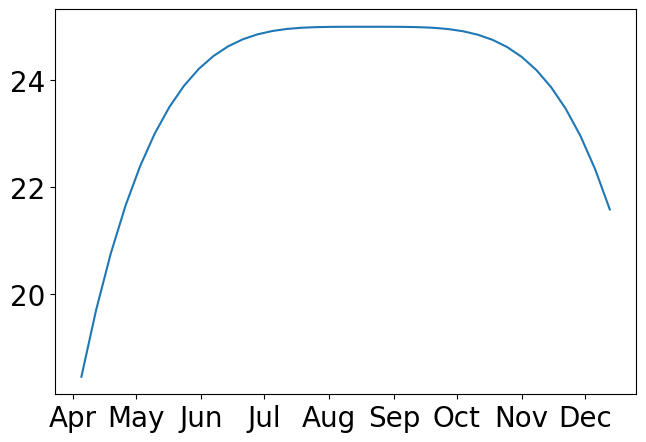

In [46]:
def generate_Tstar(amplitude, scale, offset, shift, length):
    x = np.linspace(0, length, length)
    return -(amplitude * (x + shift))**4 + offset
Tstar = generate_Tstar(0.08, 0.07, 25, -20, 37)
# plot Tstar
fig, ax = plt.subplots(1, 1, figsize=(7.5, 5))
ax.plot(mobility_dates_2020[2:], Tstar)
# format x tick labels showing month and day
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))


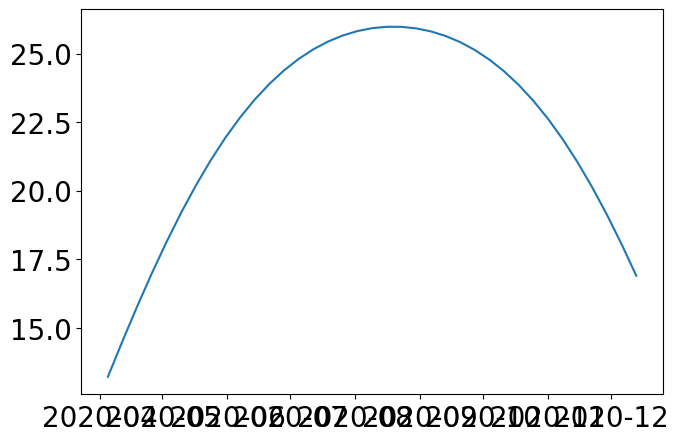

In [26]:
def generate_Tstar(amplitude, scale, offset, shift, length):
    x = np.linspace(0, length, length)
    return amplitude * np.sin(np.cos(scale * (x + shift))) + offset
Tstar = generate_Tstar(19, 0.07, 10, -20, 37)
# plot Tstar
fig, ax = plt.subplots(1, 1, figsize=(7.5, 5))
ax.plot(mobility_dates_2020[2:], Tstar)

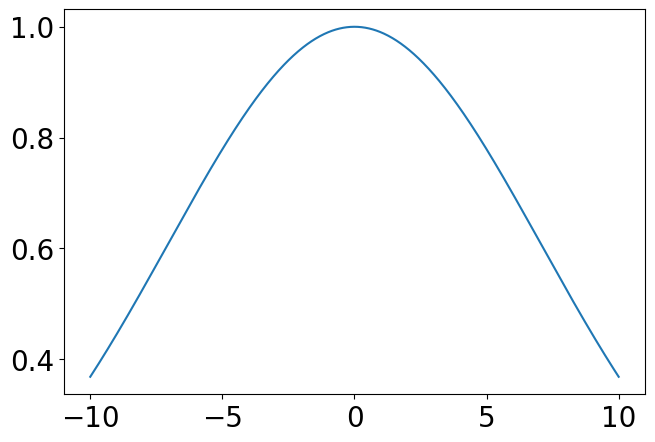

In [28]:
def Gaussian(x, a):
    return np.exp(- a * np.power(x, 2.0))
x = np.linspace(-10, 10, 1000)
y = Gaussian(x, 0.01)
# plot
fig, ax = plt.subplots(1, 1, figsize=(7.5, 5))
ax.plot(x, y)

## Home office

### Data from infas

In [5]:
df = pd.read_csv('data/home_office/home_office_infas.csv', sep='\t')

def str_to_date(date_str):
    return datetime.datetime.strptime(date_str, " %b %y")
def get_year(date):
    return date.year
def get_month(date):
    return date.month

In [6]:
# apply str_to_date() to "Month" column
df['date'] = df['Month'].apply(str_to_date)
# apply get year() to "date" column
df['year'] = df['date'].apply(get_year)
# apply get month() to "date" column
df['month'] = df['date'].apply(get_month)

In [7]:
# filter for 2020 data
df_2020 = df[df['year'] == 2020]
df_2020

,Month,WFH_rate,date,year,month
0,Apr 20,34.0,2020-04-01,2020,4
1,May 20,32.0,2020-05-01,2020,5
2,Jun 20,25.0,2020-06-01,2020,6
3,Jul 20,20.0,2020-07-01,2020,7
4,Aug 20,23.0,2020-08-01,2020,8
5,Sep 20,19.0,2020-09-01,2020,9
6,Oct 20,18.0,2020-10-01,2020,10
7,Nov 20,22.0,2020-11-01,2020,11
8,Dec 20,24.0,2020-12-01,2020,12


In [8]:
raw_rates = df_2020["WFH_rate"]

In [9]:
month_dates = [datetime.datetime(2020, i, 15) for i in range(4, 13)]

In [10]:
# make weekly data out of monthly data
column_name = "WFH_rate"
df_out = pd.DataFrame(index=mobility_dates_2020, columns=[column_name])
for week in df_out.index:
    value = df_2020.loc[(df_2020["month"] == week.month), column_name].values[0]
    df_out.loc[week, column_name] = value

### Data from ifo

In [11]:
def str_to_date(date_str):
    return datetime.datetime.strptime(date_str, " %m/%Y")

In [12]:
df = pd.read_csv('data/home_office/home_office_ifo.csv', sep='\t')

In [13]:
# apply str_to_date to the Date column
df["date"] = df["Date"].apply(str_to_date)
df["year"] = df["date"].apply(lambda x: x.year)
df["month"] = df["date"].apply(lambda x: x.month)

In [14]:
# filter for rows with year == 2022
df_2022 = df[df['year'] == 2022]

# identify which months are missing in df_2022 using the 'date' column
missing_months = [month for month in range(1, 13) if month not in df_2022['month'].unique()]

# for every missing month in df_2022, create a new row with the missing month using .concat()
for month in missing_months:
    df_2022 = pd.concat([df_2022, pd.DataFrame({'month': [month]})])

# sort df_2020 by the 'date' column
df_2022 = df_2022.sort_values(by='month')

# for the 'Percent' column interpolate the missing values
df_2022['Percent'] = df_2022['Percent'].interpolate()

df_2022

,Date,Percent,date,year,month
8,01/2022,28.400000,2022-01-01,2022.0,1
9,02/2022,28.200000,2022-02-01,2022.0,2
10,03/2022,27.600000,2022-03-01,2022.0,3
11,04/2022,24.900000,2022-04-01,2022.0,4
0,NaN,24.800000,NaT,NaN,5
0,NaN,24.700000,NaT,NaN,6
0,NaN,24.600000,NaT,NaN,7
12,08/2022,24.500000,2022-08-01,2022.0,8
0,NaN,24.666667,NaT,NaN,9
0,NaN,24.833333,NaT,NaN,10


In [15]:
# make weekly data out of monthly data
column_name = "Percent"
df_out_2022 = pd.DataFrame(index=mobility_dates_2020, columns=[column_name])
for week in df_out_2022.index:
    value = df_2022.loc[(df_2022['month'] == week.month), column_name].values[0]
    df_out_2022.loc[week, column_name] = value

In [16]:
months_2022 = [datetime.datetime(2022, i, 15) for i in [4, 8, 11]]
raw_2022 = np.array([24.9, 24.5, 25])

### Comparison plot

In [17]:
monthly_values_2022 = df_2022['Percent'].values[-9:] / 100
monthly_difference = raw_rates / 100 - monthly_values_2022

df_difference = pd.DataFrame(index=mobility_dates_2020, columns=["fraction"])
for week in df_difference.index:
    index = week.month - 4
    value = monthly_difference[index]
    df_difference.loc[week, column_name] = value

In [18]:
difference = data_prep.get_home_office_difference(mobility_dates_2020)
dates = pd.to_datetime(mobility_dates_2020)

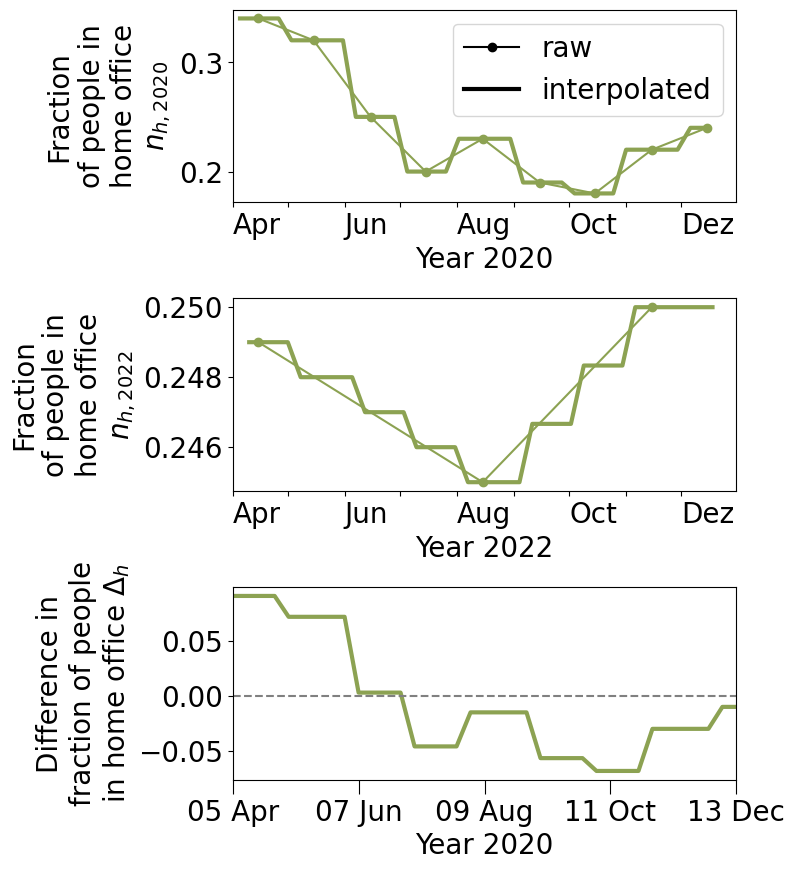

In [31]:
fig, axs = plt.subplots(3, 1, figsize=(6.5, 10))
ax = axs[0]
ax.plot(mobility_dates_2020, df_out["WFH_rate"].values/100, linewidth=3, color=plot.colors["h"])
ax.plot(month_dates, raw_rates/100, marker="o", color=plot.colors["h"])
ax.set_ylabel("Fraction\nof people in\nhome office\n$n_{h, 2020}$")
# make x ticks for beginning of every month
ax.set_xticks([datetime.datetime(2020, i, 1) for i in [4, 5, 6, 7, 8, 9, 10, 11, 12]])
# shift x tick labels with horizontal alignment to the right
ax.set_xticklabels(["Apr", "", "Jun", "", "Aug", "", "Oct", "", "Dez"], ha="left")
# set x limits from start of April to end of December
ax.set_xlim(datetime.datetime(2020, 4, 1), datetime.datetime(2020, 12, 31))
ax.set_xlabel("Year 2020")
## create custom legend
### for median line and 94% CI
raw = lines.Line2D([], [], color="black", marker='o', label="raw")
transformed = lines.Line2D([], [], color="black", linewidth=3, label="interpolated")
### create legend
ax.legend(
    handles=[raw, transformed],
    #frameon=False,
    loc="upper right",
)

ax = axs[1]
ax.plot(mobility_dates_2022_shortened, df_out_2022.values/100, linewidth=3, color=plot.colors["h"])
ax.plot(months_2022, raw_2022/100, marker="o", color=plot.colors["h"])
# make x ticks for beginning of every month
ax.set_xticks([datetime.datetime(2022, i, 1) for i in [4, 5, 6, 7, 8, 9, 10, 11, 12]])
# shift x tick labels with horizontal alignment to the right
ax.set_xticklabels(["Apr", "", "Jun", "", "Aug", "", "Oct", "", "Dez"], ha="left")
# set x limits from start of April to end of December
ax.set_xlim(datetime.datetime(2022, 4, 1), datetime.datetime(2022, 12, 31))
ax.set_xlabel("Year 2022")
ax.set_ylabel("Fraction\nof people in\nhome office\n$n_{h, 2022}$")

ax = axs[2]
ax.plot(mobility_dates_2020, difference, linewidth=3, color=plot.colors["h"])
#ax.plot(mobility_dates_2020, df_difference.values)
plot.format_x_axis(ax, dates, last=True, n_xticks=5)
ax.set_ylabel("Difference in\nfraction of people\nin home office $\Delta_h$")
ax.hlines(0, dates[0], dates[-1], linestyle="--", color="grey")

fig.subplots_adjust(hspace=0.5)

fig.savefig("figures/home_office.pdf", bbox_inches="tight")
fig.savefig("figures/home_office.png", bbox_inches="tight")

## Kurzarbeit

### Plot

In [21]:
df = pd.read_csv("data/kurzarbeit/IAB_kurzarbeit.csv", sep="\t")
df["month"] = df["Datum"].apply(data_prep.parse_month)
df["year"] = df["Datum"].apply(data_prep.parse_year)

# get 2020 data
df_2020 = df[df["year"] == 2020]
# get 2022 data
df_2022 = df[df["year"] == 2022]

In [22]:
def get_kurzarbeit_values(df):
    array = df["Kurzarbeiterquote"].values / 100
    # mirror array
    array = np.flip(array)
    return array

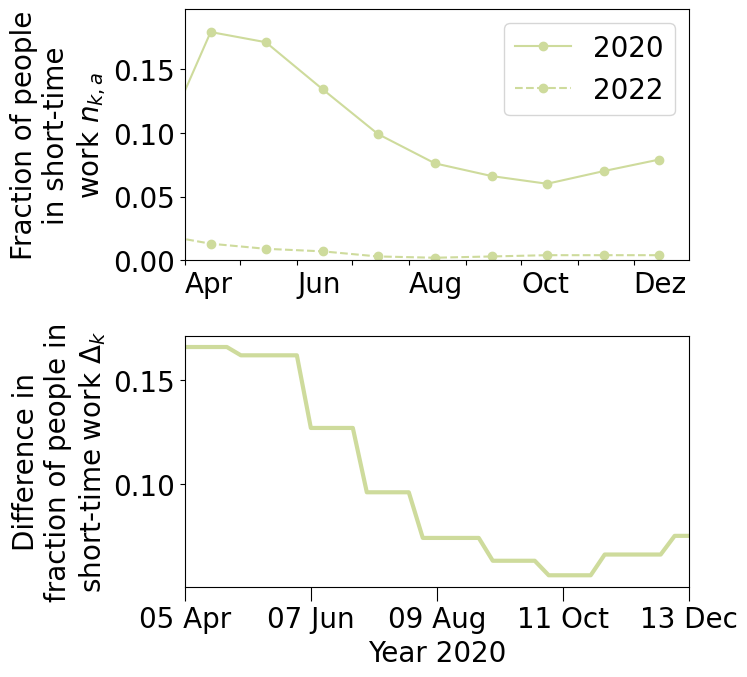

In [28]:
fig, axs = plt.subplots(2, 1, figsize=(6.5, 7.5))

ax = axs[0]
months = [datetime.datetime(2020, i, 15) for i in range(1, 13)]
ax.plot(months, get_kurzarbeit_values(df_2020), marker='o', color=plot.colors["K"], label="2020")
ax.plot(months, get_kurzarbeit_values(df_2022), marker='o', color=plot.colors["K"], linestyle="--", label="2022")
ax.legend(loc="upper right")
ax.set_ylabel("Fraction of people\nin short-time\nwork $n_{k,a}$")
# make x ticks for beginning of every month
ax.set_xticks([datetime.datetime(2020, i, 1) for i in [4, 5, 6, 7, 8, 9, 10, 11, 12]])
# shift x tick labels with horizontal alignment to the right
ax.set_xticklabels(["Apr", "", "Jun", "", "Aug", "", "Oct", "", "Dez"], ha="left")
ax.set_xlim(datetime.datetime(2020, 4, 1), datetime.datetime(2020, 12, 31))
ax.set_ylim(0, max(get_kurzarbeit_values(df_2020)) * 1.1)

ax = axs[1]
ax.plot(mobility_dates_2020, data_prep.get_kurzarbeit(mobility_dates_2020), color=plot.colors["K"], linewidth=3)
plot.format_x_axis(ax, dates, last=True, n_xticks=5)
ax.set_ylabel("Difference in\nfraction of people in\nshort-time work $\Delta_k$")

fig.subplots_adjust(hspace=0.3)

fig.savefig("figures/kurzarbeit.pdf", bbox_inches="tight")
fig.savefig("figures/kurzarbeit.png", bbox_inches="tight")

### IAB

In [5]:
df = pd.read_csv('data/kurzarbeit/IAB_kurzarbeit.csv', sep='\t')

In [6]:
def parse_month(date_str):
    strings = date_str.split(' ')
    month = data_prep.german_month_to_num(strings[0])
    return month
def parse_year(date_str):
    strings = date_str.split(' ')
    year = int(strings[1])
    return year

In [7]:
# apply parse_month() to "Datum" column
df["month"] = df["Datum"].apply(parse_month)
# apply parse_year() to "Datum" column
df["year"] = df["Datum"].apply(parse_year)
df.head()

,Datum,-,-.1,Kurzarbeitende,-.2,-.3,Beschäftigungsäquivalent,Kurzarbeiterquote,month,year
0,Januar 2023,"8,906","3,553","144,546","112,029","32,517","41,398",0.4,1,2023
1,Dezember 2022,"8,538","3,553","145,794","112,937","32,857","39,695",0.4,12,2022
2,November 2022,"9,154","3,537","146,637","114,636","32,001","40,896",0.4,11,2022
3,Oktober 2022,"7,681","2,974","124,208","97,581","26,627","32,927",0.4,10,2022
4,September 2022,"6,200","2,335","97,396","76,636","20,760","25,103",0.3,9,2022


In [17]:
# get 2020 data
df_2020 = df[df['year'] == 2020]
# get 2022 data 
df_2022 = df[df['year'] == 2022]
# calculate the difference between 2020 and 2022
delta_kurzarbeit = df_2020['Kurzarbeiterquote'].values - df_2022['Kurzarbeiterquote'].values

In [23]:
df_2020

,Datum,-,-.1,Kurzarbeitende,-.2,-.3,Beschäftigungsäquivalent,Kurzarbeiterquote,month,year
25,Dezember 2020,"363,544","33,216","2,675,968","1,391,391","1,284,577","1,229,831",7.9,12,2020
26,November 2020,"312,009","35,294","2,386,194","1,375,646","1,010,548","1,114,622",7.0,11,2020
27,Oktober 2020,"236,642","35,137","2,020,651","1,264,524","756,127","752,339",6.0,10,2020
28,September 2020,"250,115","37,279","2,229,430","1,395,249","834,181","803,719",6.6,9,2020
29,August 2020,"279,306","39,047","2,537,053","1,565,230","971,823","912,938",7.6,8,2020
30,Juli 2020,"327,509","44,584","3,305,887","2,035,360","1,270,527","1,239,707",9.9,7,2020
31,Juni 2020,"412,537","50,752","4,452,284","2,699,440","1,752,844","1,680,619",13.4,6,2020
32,Mai 2020,"536,284","56,040","5,714,841","3,349,246","2,365,595","2,433,427",17.1,5,2020
33,April 2020,"609,681","53,504","5,995,428","3,376,975","2,618,453","3,049,142",17.9,4,2020
34,März 2020,"342,426","21,855","2,579,665","1,389,348","1,190,317","867,967",7.7,3,2020


In [33]:
column_name = "Differenz Kurzarbeiteranteil"
df_diff = pd.DataFrame(index=df_2020["month"])
df_diff[column_name] = delta_kurzarbeit / 100
df_out = pd.DataFrame(index=mobility_dates_2020, columns=[column_name])
for week in df_out.index:
    value = df_diff.loc[(df_diff.index == week.month), column_name].values[0]
    df_out.loc[week, column_name] = round(value, 3)

<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>


In [40]:
df_out[column_name] = df_out[column_name].astype(float)
df_out[column_name].values

array([0.166, 0.166, 0.166, 0.166, 0.162, 0.162, 0.162, 0.162, 0.162,
       0.127, 0.127, 0.127, 0.127, 0.096, 0.096, 0.096, 0.096, 0.074,
       0.074, 0.074, 0.074, 0.074, 0.063, 0.063, 0.063, 0.063, 0.056,
       0.056, 0.056, 0.056, 0.066, 0.066, 0.066, 0.066, 0.066, 0.075,
       0.075])

In [38]:
# to xarray
array = df_out.to_xarray()
# name dims to date
array = array.rename_dims({'index':'date'})
array.data_vars["Differenz Kurzarbeiteranteil"].values[0] - 1

-0.834

### Old

In [12]:
dates_in = mobility_dates_2020

NameError: name 'mobility_dates_2020' is not defined

In [25]:
df = pd.read_csv('data/home_office_kurzarbeit/home_office.csv')
df

,month,Gesamtwirtschaft in percent
0,Feb '21,30.3
1,Mär '21,31.7
2,Apr '21,30.8
3,Mai '21,31.0
4,Jun '21,28.4
5,Jul '21,25.5
6,Aug '21,23.8
7,Dez '21,27.9
8,Jan '22,28.4
9,Feb '22,28.2


In [14]:
df = pd.read_csv('data/home_office_kurzarbeit.csv')
# get only 2020 data: filter for month < 13
df = df[df['month'] < 13]

array([ 4,  5,  6,  7,  8,  9, 10, 11, 12])

In [22]:
# make weekly data out of daily data
df_2020 = pd.DataFrame(index=dates_in, columns=["percent"])
for week in df_2020.index:
    value = df.loc[(df["month"] == week.month), "percent"].values[0]
    df_2020.loc[week, "percent"] = value

In [24]:
kurzarbeit_df = data_prep.get_total_kurzarbeit()
df_kurzarbeit_2022 = data_prep.get_weekly_kurzarbeit(kurzarbeit_df, mobility_dates_2022_shortened, "2022")
population = 83237124
KA_2022 = df_kurzarbeit_2022["Anzahl Kurzarbeitende"].values
KA_diff = df_2020["percent"].values - KA_2022 / population
KA_diff_xr = xr.DataArray(KA_diff, coords=[dates_in], dims=["date"])


In [26]:
KA_diff - 0.24

array([51.79455852174806, 51.79455852174806, 51.79455852174806,
       51.79617588901798, 49.20117588901798, 49.20117588901798,
       49.20117588901798, 49.20117588901798, 49.202105798609765,
       38.63110579860977, 38.63110579860977, 38.63110579860977,
       38.63262212923166, 29.665622129231664, 29.665622129231664,
       29.665622129231664, 29.665622129231664, 30.40294942309636,
       30.40294942309636, 30.40294942309636, 30.40294942309636,
       30.402701733135327, 25.420701733135328, 25.420701733135328,
       25.420701733135328, 25.420390682023083, 23.945390682023085,
       23.945390682023085, 23.945390682023085, 23.945390682023085,
       28.928131002219637, 28.928131002219637, 28.928131002219637,
       28.928131002219637, 28.92523194722586, 32.03223194722585,
       32.03223194722585], dtype=object)

In [9]:
def german_month_to_num(month):
    german_months = ['Januar', 'Februar', 'März', 'April', 'Mai', 'Juni', 'Juli', 'August', 'September', 'Oktober', 'November', 'Dezember']         
    return german_months.index(month) + 1

df = pd.read_csv('data/kurzarbeit.csv', sep=';')
df['year'] = df['Berichtsmonat'].str[-4:]
df['month'] = df['Berichtsmonat'].str[:-5]

# turn month names into numbers with german_month_to_num function
df['month'] = df['month'].apply(german_month_to_num)
#df.head()

,Berichtsmonat,Anzahl Kurzarbeitende,year,month
0,Dezember 2022,396879,2022,12
1,November 2022,155570,2022,11
2,Oktober 2022,133955,2022,10
3,September 2022,108064,2022,9
4,August 2022,87447,2022,8


In [23]:
def get_weekly_kurzarbeit(df_in, dates_in, year_in):
    # create new df with mobility_dates_2020 as index and Anzahl Kurzarbeitende of the corresponding month as column
    df_out = pd.DataFrame(index=dates_in, columns=['Anzahl Kurzarbeitende'])
    # now assign for each week the number of Kurzarbeitende of the month corresponding to the week
    for week in df_out.index:
        # get value of 'Anzahl Kurzarbeitende' in df for column 'month' week.month and 'year' 2020
        value = df_in.loc[(df_in['month'] == week.month) & (df_in['year'] == year_in), 'Anzahl Kurzarbeitende'].values[0]
        df_out.loc[week, 'Anzahl Kurzarbeitende'] = value
    return df_out
df_kurzarbeit_2020 = get_weekly_kurzarbeit(df, mobility_dates_2020, '2020')
df_kurzarbeit_2022 = get_weekly_kurzarbeit(df, mobility_dates_2022_shortened, '2022')

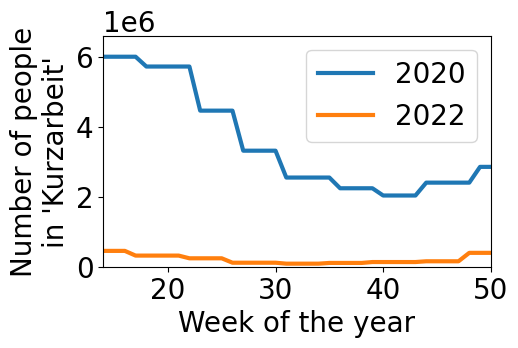

In [42]:
weeks = mobility_df_2020.week.values
# plot kurzarbeit for both years
fig, ax = plt.subplots(figsize=(5, 3))
# set linewidth to 3
lw = 3
KA_2020 = df_kurzarbeit_2020['Anzahl Kurzarbeitende'].values
KA_2022 = df_kurzarbeit_2022['Anzahl Kurzarbeitende'].values
ax.plot(weeks, KA_2020, label='2020', lw=lw)
ax.plot(weeks, KA_2022, label='2022', lw=lw)
ax.set_xlabel('Week of the year')
# set xlim
ax.set_xlim(weeks[0], weeks[-1])
# set ylim
ax.set_ylim(0, 1.1*max(df_kurzarbeit_2020['Anzahl Kurzarbeitende'].values))
ax.set_ylabel("Number of people\nin 'Kurzarbeit'")
ax.legend()

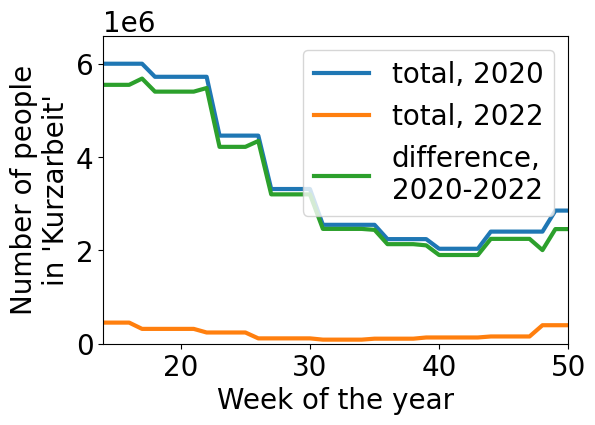

In [45]:
weeks = mobility_df_2020.week.values
# plot kurzarbeit for both years
fig, ax = plt.subplots(figsize=(6, 4))
# set linewidth to 3
lw = 3
KA_2020 = df_kurzarbeit_2020['Anzahl Kurzarbeitende'].values
KA_2022 = df_kurzarbeit_2022['Anzahl Kurzarbeitende'].values
ax.plot(weeks, KA_2020, label='total, 2020', lw=lw)
ax.plot(weeks, KA_2022, label='total, 2022', lw=lw)
ax.plot(weeks, KA_2020-KA_2022, label='difference,\n2020-2022', lw=lw)
ax.set_xlabel('Week of the year')
# set xlim
ax.set_xlim(weeks[0], weeks[-1])
# set ylim
ax.set_ylim(0, 1.1*max(df_kurzarbeit_2020['Anzahl Kurzarbeitende'].values))
ax.set_ylabel("Number of people\nin 'Kurzarbeit'")
ax.legend()

In [50]:
def population_string_to_number(string_in):
    string = string_in.replace("\xa0", "")
    return int(string)
population_bundesland = pd.read_csv("data/mobility/population_bundesland.csv", delimiter=";", index_col=0)
# apply format function to population column
population_bundesland["Einwohner"] = population_bundesland["Einwohner"].apply(population_string_to_number)
# sum up all states to get the total population
population_germany = population_bundesland["Einwohner"].sum()
population_germany

83237124

Text(0.5, 1.0, "'Kurzarbeit' (2020 vs. 2022)")

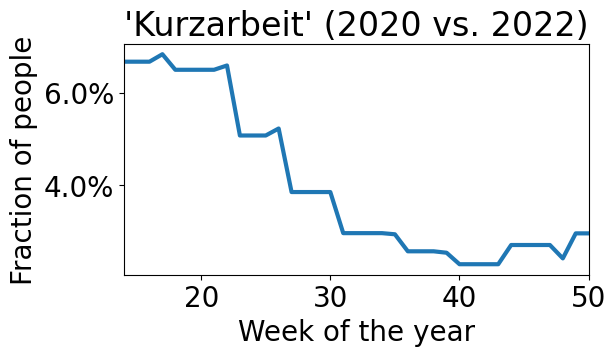

In [58]:
import matplotlib.ticker as mtick
population = 83237124
weeks = mobility_df_2020.week.values
# plot kurzarbeit for both years
fig, ax = plt.subplots(figsize=(6, 3))
# set linewidth to 3
lw = 3
KA_2020 = df_kurzarbeit_2020['Anzahl Kurzarbeitende'].values
KA_2022 = df_kurzarbeit_2022['Anzahl Kurzarbeitende'].values
values = (KA_2020-KA_2022)/population
ax.plot(weeks, values, label='difference,\n2020-2022', lw=lw)
ax.set_xlabel('Week of the year')
# set xlim
ax.set_xlim(weeks[0], weeks[-1])
# set ylim
#ax.set_ylim(0, 1.1*max(df_kurzarbeit_2020['Anzahl Kurzarbeitende'].values))
# format y ticks as percentages
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel("Fraction of people")
ax.set_title("'Kurzarbeit' (2020 vs. 2022)")
#ax.legend()

In [ ]:
# order for later? 
# take whole data set, correct for reporting delays, then split up into years
# problem: probably no reporting delay in e.g. 2022
# then weekly formatting
# then calculate differences as input for modulation factor

## Visualise and compare

(12.0, 51.0)

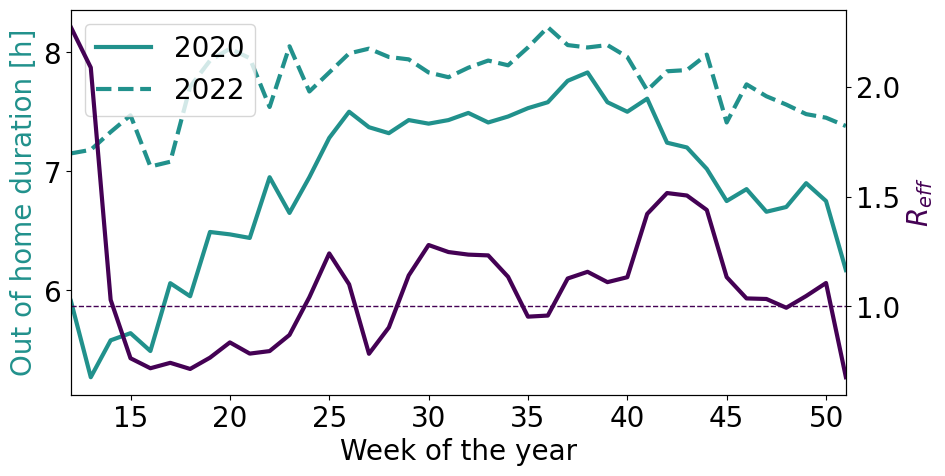

In [10]:
# plot mobility and R data
color_R = colormap(0)
color_m = colormap(0.5)

min_x = mobility_df_2020["week"].min()
max_x = mobility_df_2020["week"].max()

fig, ax = plt.subplots(figsize=(10, 5))
ax_R = ax.twinx()
ax.plot(mobility_df_2020["week"], mobility_df_2020["outOfHomeDuration"], label="2020", linewidth=3, color=color_m_R)
ax.plot(mobility_df_2020["week"], mobility_df_2022["outOfHomeDuration"], label="2022", linewidth=3, color=color_m_base, linestyle="--")
ax_R.plot(mobility_df_2020["week"], R_df_weekly_shortened["R_eff median"], linewidth=3, color=color_R)
ax_R.hlines(1, min_x, max_x, color=color_R, linestyle="--", linewidth=1)
ax.legend(loc="upper left")
ax.set_xlabel("Week of the year") # THIS IS NOT COMPLETELY CORRECT AS 2022 IS ONLY 51 WEEKS LONG
ax.set_ylabel("Out of home duration [h]", color=color_m)
ax_R.set_ylabel(f"$R_{{eff}}$", color=color_R)
ax.set_xlim(min_x, max_x)

In [24]:
## Out of home duration
path_mobility = "data/mobility/mobilityData_OverviewBL_weekly.csv"
mobility_df = pd.read_csv(path_mobility, parse_dates=True, index_col=0, delimiter=";")
mobility_df = mobility_df[mobility_df["BundeslandID"] == "Deutschland"]
mobility_df["week"] = mobility_df.index.isocalendar().week

### get dates
mobility_dates = mobility_df.index.values
mobility_dates_2020 = mobility_dates[mobility_dates < np.datetime64("2020-12-20")]
mobility_dates_2020 = mobility_dates_2020[
    mobility_dates_2020 > np.datetime64("2020-03-29")
]
mobility_dates_2022 = mobility_dates[mobility_dates < np.datetime64("2022-12-20")]
mobility_dates_2022_shortened = mobility_dates_2022[-len(mobility_dates_2020) :]

### get out of home duration data
mobility_df_2020 = mobility_df.filter(items=mobility_dates_2020, axis=0)
mobility_data_2020 = mobility_df_2020["outOfHomeDuration"].to_xarray()

baseline_mobility_df = pd.read_csv(
    "data/mobility/baseline_mobility.csv", parse_dates=True, index_col=0
)
baseline_mobility_df = baseline_mobility_df.filter(
    items=mobility_dates_2022_shortened, axis=0
)
## replace index by mobility_dates_2020
baseline_mobility_df.index = mobility_dates_2020
## rename index to "date"
baseline_mobility_df.index.name = "date"
baseline_mobility = baseline_mobility_df["outOfHomeDuration"].to_xarray()

## R
path_R = "data/R/Germany/R_eff_Germany.csv"
R_df = pd.read_csv(path_R, index_col=1, parse_dates=True)

### weekly average placed on Sunday
df = utils.weekly_formatting(R_df, mobility_dates_2020)
df2 = utils.transform_data(df["R_eff median"])
R_data = df2.to_xarray()

## NPI
stay_at_home_2020_raw = utils.get_NPI_data(
    "data/NPIs/stay-at-home-covid.csv", mobility_dates_2020
)
stay_at_home_2020 = utils.transform_data(stay_at_home_2020_raw)
stay_at_home_2020 = stay_at_home_2020["stay_home_requirements"].to_xarray()

## Temperature
weather_df = pd.read_csv(
    "data/weather/weatherData2020and2022.csv", parse_dates=True, index_col=0
)

### filter for mobility_dates_2020
weather_df_2020 = weather_df[weather_df.index.isin(mobility_dates_2020)]
weather_df_2022 = weather_df[weather_df.index.isin(mobility_dates_2022_shortened)]

### calculate differences between the years
delta_tmax = utils.return_differences(weather_df_2020, weather_df_2022, "tmax")
delta_tmax = xr.DataArray(
    delta_tmax, dims="date", coords={"date": mobility_dates_2020}, name="delta_tmax"
)

### calculate average between the years
average_tmax = utils.return_averages(weather_df_2020, weather_df_2022, "tmax")
average_tmax = xr.DataArray(
    average_tmax, dims="date", coords={"date": mobility_dates_2020}, name="average_tmax"
)

# convert dates to datetime
dates = pd.to_datetime(mobility_dates_2020)

1
1.0


/data/eiftekhar/mobility_inference/utils.py:19: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = df.resample("7D").mean()


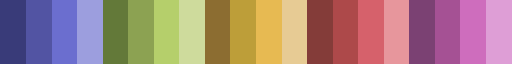

In [67]:
# colormap for plots
from matplotlib import colormaps
colormap = colormaps['tab20b']
colormap

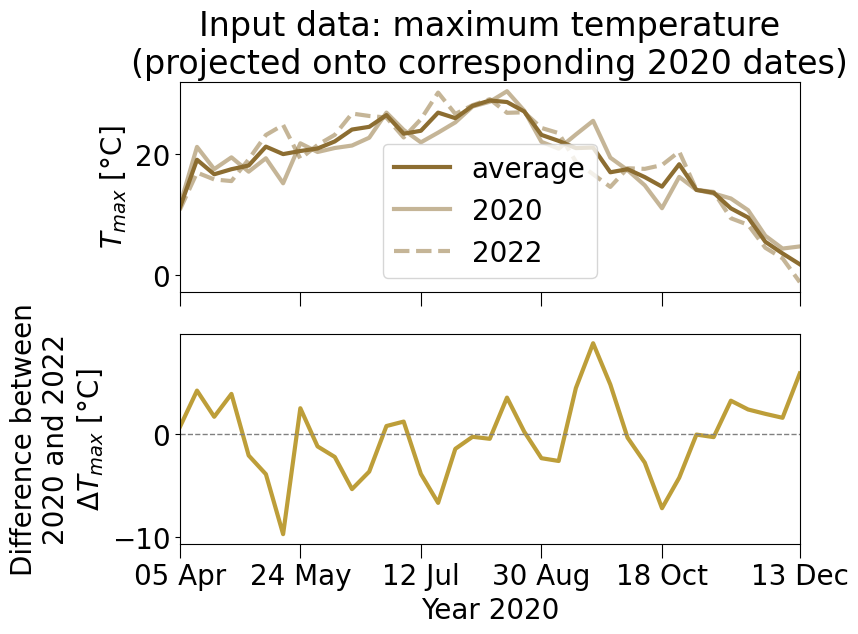

In [45]:
color_T = colormap(0.4)
color_delT = colormap(0.45)


fig, axs = plt.subplots(2, 1, figsize=(8, 6))

# plot weekly R_eff data
ax = axs[0]
ax.set_title("Input data: maximum temperature\n(projected onto corresponding 2020 dates)")
ax.plot(dates, average_tmax.values, linewidth=3, color=color_T, label="average")
ax.plot(dates, weather_df_2020["tmax"].values, linewidth=3, color=color_T, alpha=0.5, label="2020")
ax.plot(dates, weather_df_2022["tmax"].values, linewidth=3, color=color_T, alpha=0.5, linestyle="--", label="2022")
ax.legend()
ax.set_ylabel("$T_{max}$ [°C]")#\n(average between 2020 and 2022)")
format_x_axis(ax, dates)
#ax = axs[0].twinx()
#ax.plot(dates, stay_at_home_2020_raw["stay_home_requirements"], linewidth=3, color=color_S, label="Stay at home")
#ax.set_ylabel(f"Stay-at-home\norder index", color=color_S)

ax = axs[1]
ax.plot(dates, delta_tmax.values, linewidth=3, color=color_delT)
ax.set_ylabel("Difference between\n2020 and 2022\n$\Delta T_{max}$ [°C]")
ax.hlines(0, dates[0], dates[-1], color="grey", linestyle="--", linewidth=1)
format_x_axis(ax, dates, last=True)

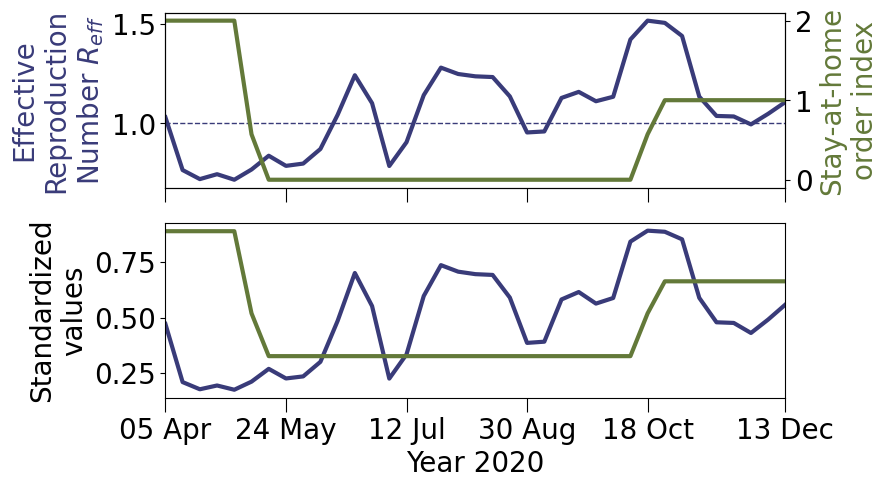

In [46]:
color_R = colormap(0.0)
color_S = colormap(0.2)


fig, axs = plt.subplots(2, 1, figsize=(8, 5))

# plot weekly R_eff data
ax = axs[0]
ax.plot(dates, df["R_eff median"], linewidth=3, color=color_R, label="$R_{{eff}}$")
ax.hlines(1, dates[0], dates[-1], linestyle="--", linewidth=1, color=color_R)
ax.set_ylabel("Effective\nReproduction\nNumber $R_{eff}$", color=color_R)
format_x_axis(ax, dates)
ax = axs[0].twinx()
ax.plot(dates, stay_at_home_2020_raw["stay_home_requirements"], linewidth=3, color=color_S, label="Stay at home")
ax.set_ylabel(f"Stay-at-home\norder index", color=color_S)

ax = axs[1]
ax.plot(dates, R_data, linewidth=3, color=color_R, label="$R_{{eff}}$")
ax.plot(dates, stay_at_home_2020, linewidth=3, color=color_S, label="Stay at home")
ax.set_ylabel(f"Standardized\nvalues")
format_x_axis(ax, dates, last=True)

# Play around with functions

In [33]:
import pymc as pm

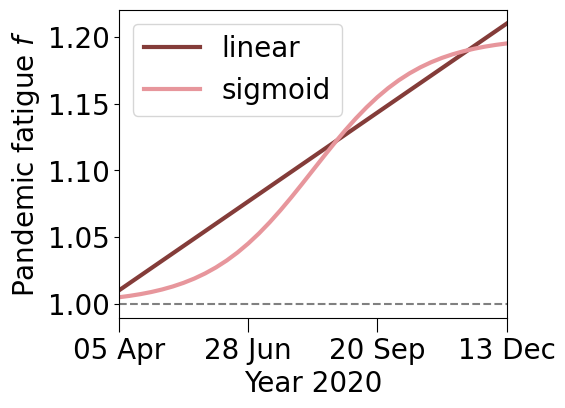

In [63]:
# simple linear plot
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
length = len(dates_2020)
x = np.linspace(0, length, length)

p0 = 0.01
r = 0.2 / length
y = 1 + p0 + r * x
ax.plot(dates_2020, y, color=plot.colors["f"], linewidth=3, label="linear")

del_t = - length / 2
del_f = 0.2
tau = 0.2
y = model.sigmoid(x, del_t, del_f, tau).eval()
ax.plot(dates_2020, y, color=plot.colors["sigmoid"], linewidth=3, label="sigmoid")

ax.hlines(1, dates_2020[0], dates_2020[-1], linestyle="--", color="grey")
ax.set_ylabel("Pandemic fatigue $f$")
plot.format_x_axis(ax, dates_2020, last=True, n_xticks=4)
ax.legend(loc="upper left")

# save figure
fig.savefig("figures/pandemic_fatigue.pdf", bbox_inches="tight")
fig.savefig("figures/pandemic_fatigue.png", bbox_inches="tight")

Mean:  3.2974425414002564


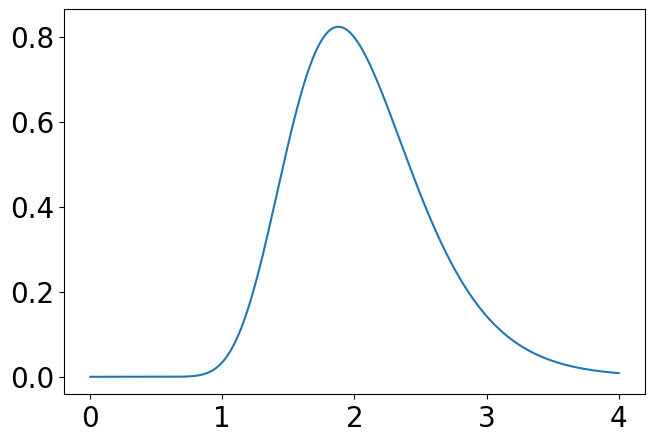

In [66]:
def LogNormal(x, mu, tau):
    return 1/x * np.sqrt(tau / 2 / math.pi) * np.exp(- tau / 2 * np.power(np.log(x) - mu, 2.0))
x = np.linspace(0.001, 4, 1000)
mu = np.log(2)
tau = 1
sigma = 0.25
print("Mean: ", np.exp(mu + 1/2/tau))
y = np.exp(pm.logp(pm.LogNormal.dist(mu, sigma=sigma), x).eval())
#y2 = np.exp(pm.logp(pm.LogNormal.dist(mu, tau=9), x).eval())
# plot
fig, ax = plt.subplots(1, 1, figsize=(7.5, 5))
ax.plot(x, y)
#ax.plot(x, y2)

# for Gamma-mu = 1: mu=np.log(1), sigma=0.5
# robustness test: sigma verdoppeln und gucken wie sich Resultate ändern

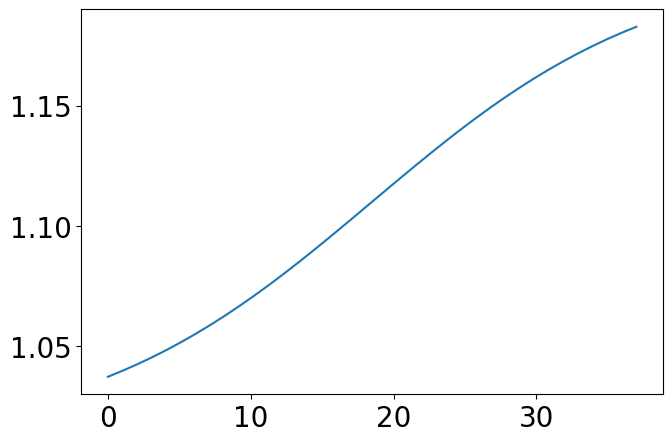

In [14]:
def sigmoid(x, del_t, a, p0, b):
    return a / (1 + np.exp(-0.1*(x - del_t))) + p0
len = 37
x = np.linspace(0, len, len)
y = sigmoid(x, del_t=len / 2, a=0.2, p0=1.01, b=0.5)
# plot
fig, ax = plt.subplots(1, 1, figsize=(7.5, 5))
ax.plot(x, y)


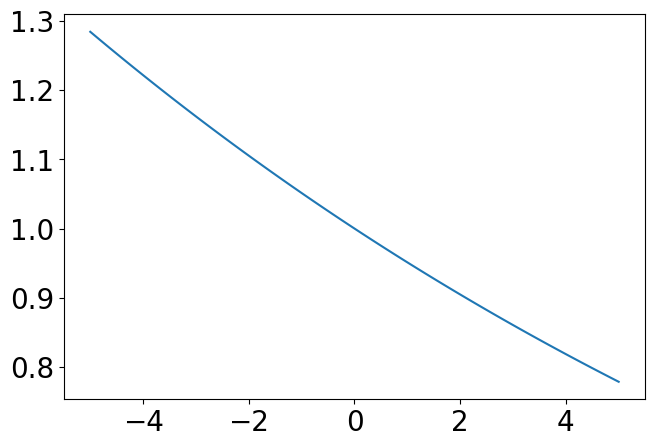

In [24]:
def exp(x, a, b):
    return b * np.exp(-a*x)
len = 37
x = np.linspace(-5, 5, 100)
y = exp(x, a=0.05, b=1)

# plot
fig, ax = plt.subplots(1, 1, figsize=(7.5, 5))
ax.plot(x, y)
## log scale for y axis
#ax.set_yscale("log")


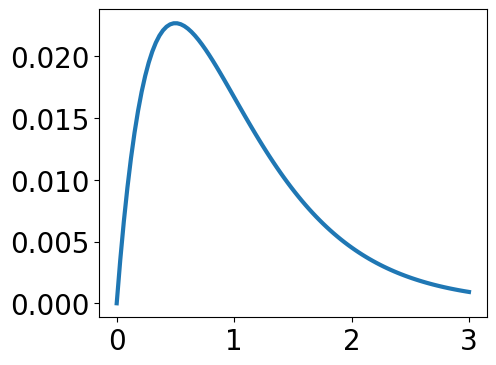

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

# plot
mu = 1
alpha = 2
beta = alpha / mu
x = np.linspace(0, 3*mu, 100)
y = cov19.model._utility.tt_gamma(
    x,
    alpha=alpha,
    beta=beta,
).eval()
ax.plot(x, y, linewidth=3)
